In [18]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [19]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [20]:
base_dir = Path("/home/workspace/projects/drg")
#base_dir = Path("/home/workspace/temp/madv2/")

input_dir = os.path.join(base_dir, 'h5ad/export_03/')

### Read and process adata

In [21]:
adata = sc.read_h5ad(os.path.join(input_dir, 'adata-scvi-leiden-annotated.h5ad'))
adata

AnnData object with n_obs × n_vars = 95966 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'neighbors', 'umap'
    

## Compare to Leiden clusters

In [22]:
#sc.pl.umap(adata, color = ['Epcam', 'Ptprc', 'Acta2', 'Col1a1'])

In [23]:
#sc.pl.umap(adata, color = ['scanvi_labels_xenium'], frameon = False)

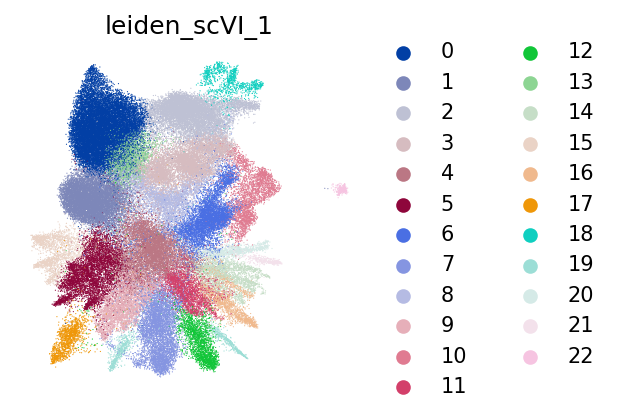

In [24]:
sc.pl.umap(adata, color = ['leiden_scVI_1'], frameon = False)

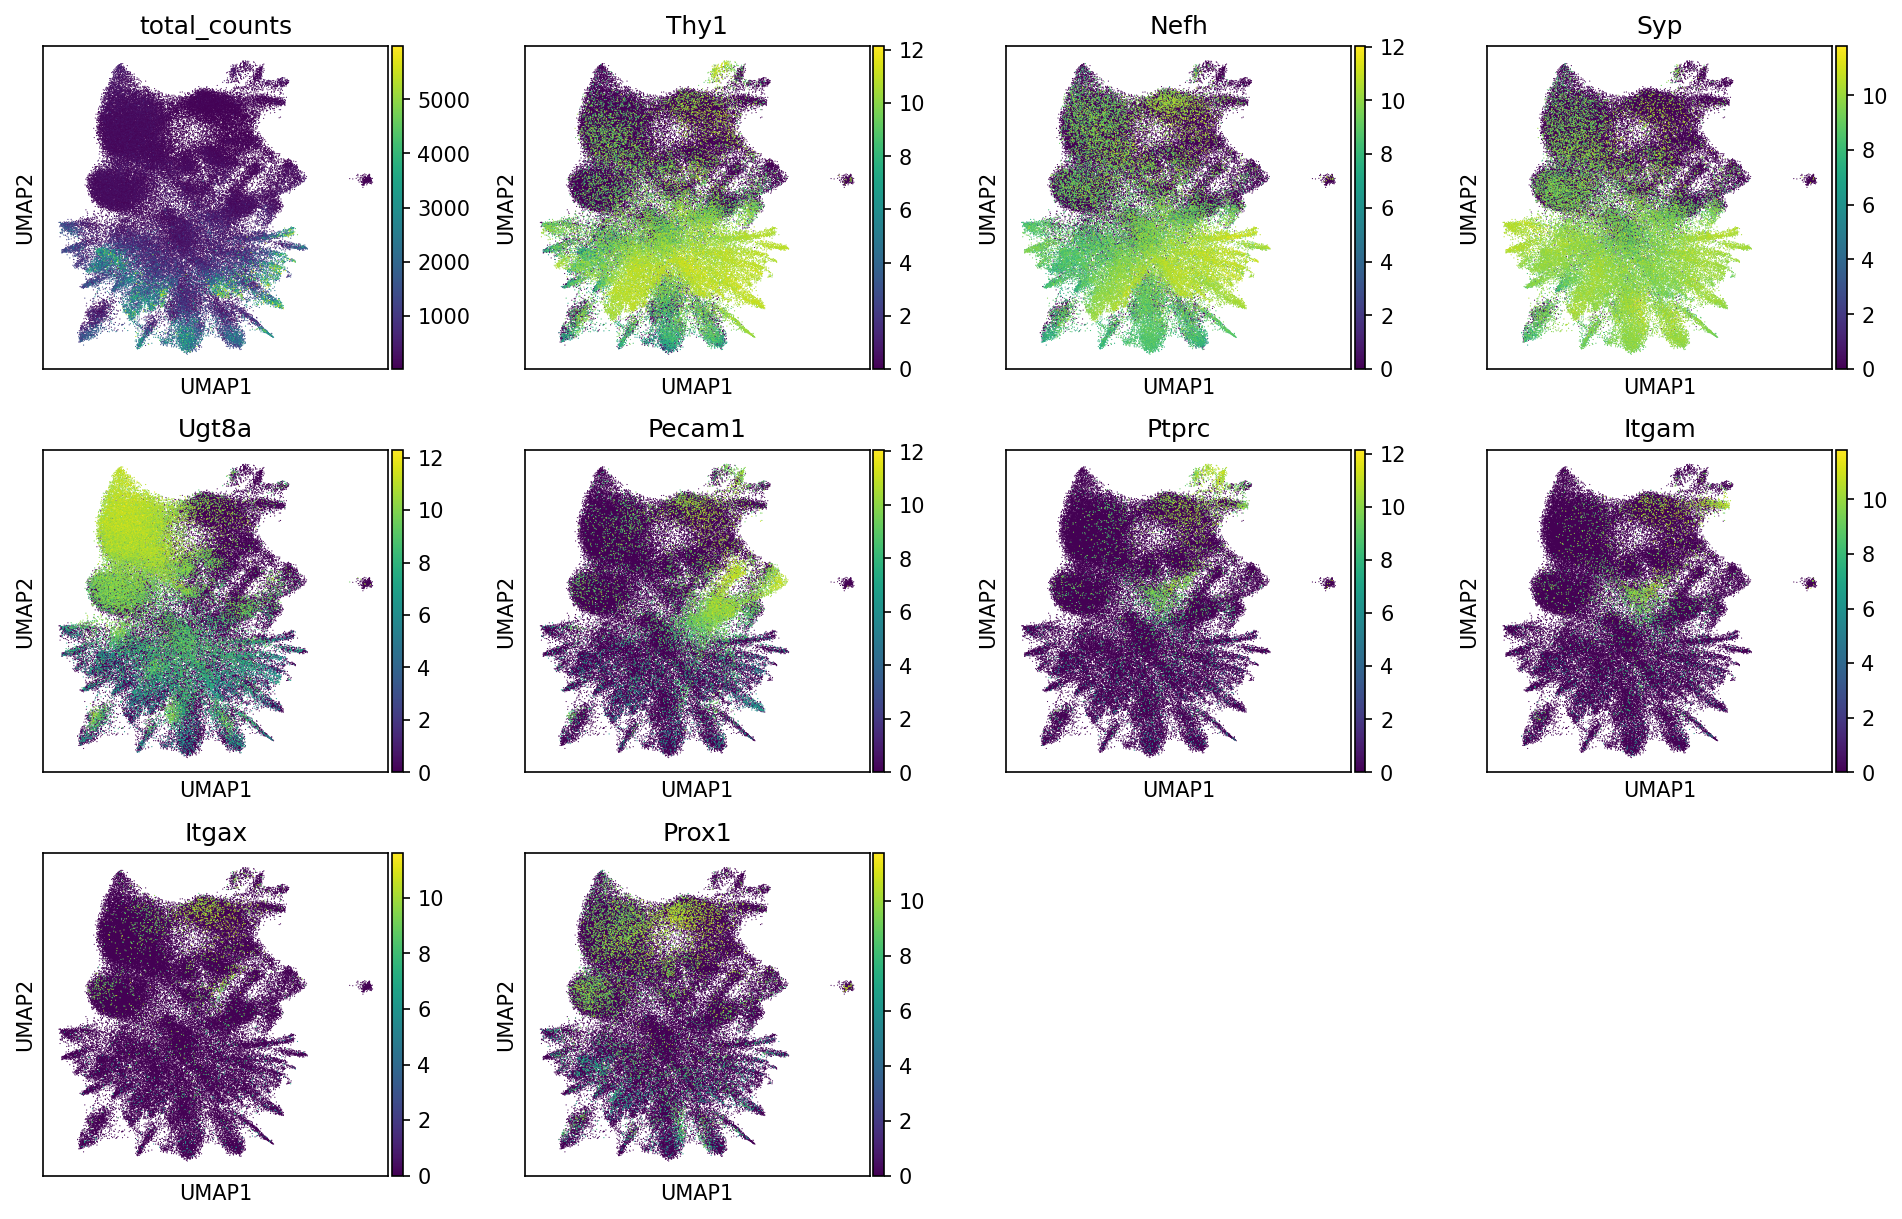

In [25]:
sc.pl.umap(adata, color = ['total_counts','Thy1', 'Nefh', 'Syp', 'Ugt8a', 'Pecam1', 'Ptprc', 'Itgam', 'Itgax', 'Prox1'])

# Evaluate co-expression

In [26]:
adata.obs['cell_type'] = adata.obs['leiden_scVI_1'].copy()

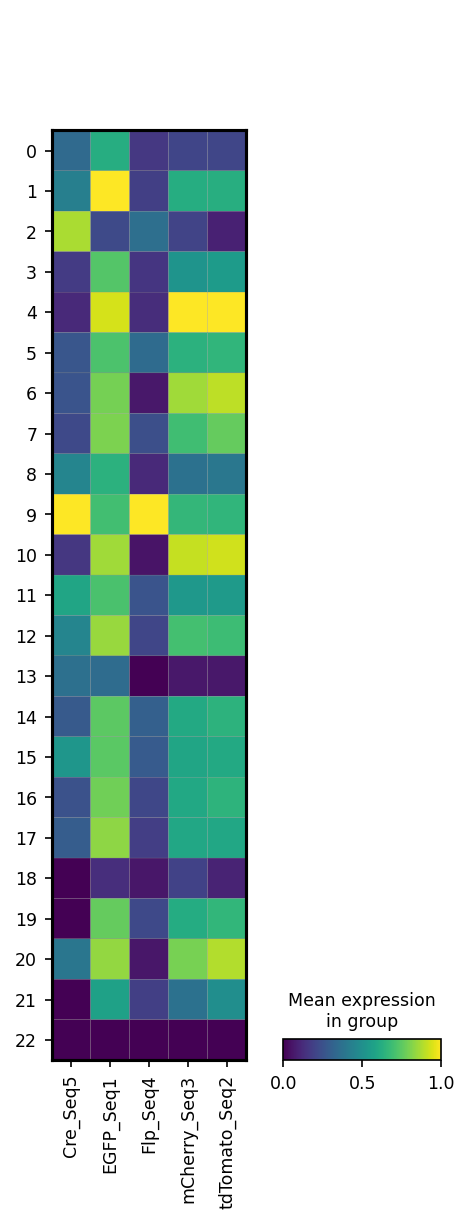

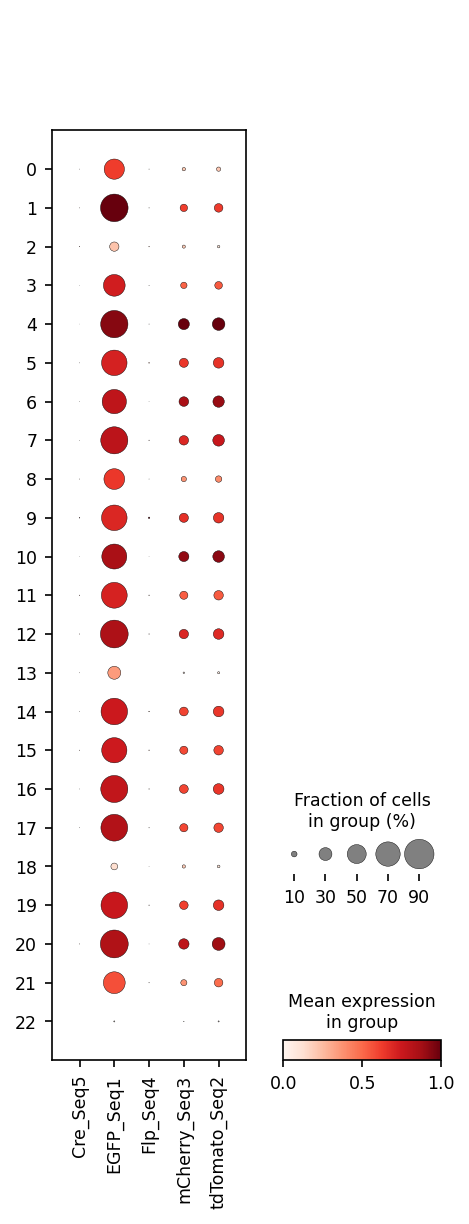

In [27]:
genes = ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']
sc.pl.matrixplot(adata, var_names = genes, groupby = 'leiden_scVI_1', standard_scale = 'var')
sc.pl.dotplot(adata, var_names = genes, groupby = 'leiden_scVI_1', standard_scale = 'var')

In [32]:
#genes = ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']
#genes = ['Cre_Seq5', 'Flp_Seq4']
genes = ['EGFP_Seq1', 'tdTomato_Seq2']


adata_subset = adata[:, genes]

df = pd.DataFrame(
    adata_subset.X.toarray(),  # convert sparse to dense if needed
    columns=genes,
    index=adata.obs['cell_type']
)

# Average expression per cell type
mean_expr = df.groupby(level=0).mean()

# Count cells expressing all three (simple >0 threshold)
mask = (df[genes] > 0).all(axis=1)
colocalizing_counts = df[mask].index.value_counts()

print("Mean expression per cell type:")
print(mean_expr)
print("\nNumber of cells co-expressing all genes per cell type:")
print(colocalizing_counts)

Mean expression per cell type:
           EGFP_Seq1  tdTomato_Seq2
cell_type                          
0           1.117729       0.076466
1           2.750729       0.216978
2           0.281954       0.036897
3           1.861670       0.194233
4           3.476059       0.440801
5           2.693139       0.321955
6           1.934161       0.361772
7           3.189426       0.367913
8           1.341333       0.151515
9           3.352084       0.783687
10          2.862838       0.396622
11          2.878439       0.275836
12          3.369546       0.332024
13          0.470746       0.028138
14          3.139201       0.320162
15          2.493036       0.272052
16          3.665483       0.333925
17          3.026893       0.250531
18          0.282847       0.056569
19          2.839154       0.318015
20          3.793000       0.414000
21          1.818713       0.257310
22          0.011450       0.011450

Number of cells co-expressing all genes per cell type:
cell_type
4  

In [33]:
# Keep only genes that exist to avoid KeyErrors
present = [g for g in genes if g in adata.var_names]
if len(present) < 2:
    raise ValueError(f"Need at least 2 of {genes} in adata.var_names; found {present}")

# Subset and materialize to dense if needed
X = adata[:, present].X
if sparse.issparse(X):
    X = X.toarray()

# Build per-cell dataframe
df = pd.DataFrame(X, columns=present)
df["cell_type"] = adata.obs["cell_type"].values

# Compute, for each cell type, the mean of the upper-triangular Spearman correlations among the genes
rows = []
for ct, gdf in df.groupby("cell_type", sort=False):
    # Skip if fewer than 3 cells; correlations are unstable
    if len(gdf) < 3:
        rows.append((ct, np.nan, len(gdf)))
        continue
    corr = gdf[present].corr(method="spearman")
    # Extract upper triangle without diagonal
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    vals = corr.where(mask).stack()
    score = vals.mean() if not vals.empty else np.nan
    rows.append((ct, score, len(gdf)))

# Summary table: higher score => tighter co-variation (more likely infected cell type)
scores = pd.DataFrame(rows, columns=["cell_type", "spearman_coexpr_score", "n_cells"])
scores = scores.dropna().sort_values(["spearman_coexpr_score", "n_cells"], ascending=[False, False]).reset_index(drop=True)

print(scores.head(20))  # top candidates

   cell_type  spearman_coexpr_score  n_cells
0         10               0.392501     2960
1         19               0.319467     1088
2          7               0.319262     5485
3         16               0.314033     1689
4          6               0.308189     5802
5          5               0.307816     5830
6         21               0.300750      342
7         20               0.297484     1000
8         15               0.293463     2154
9         17               0.268080     1413
10        14               0.266792     2227
11         4               0.255619     6892
12         8               0.250557     4125
13         9               0.246880     3911
14         3               0.244934     7352
15        12               0.236591     2292
16        11               0.224798     2690
17        18               0.222350     1096
18         1               0.167991     9259
19         0               0.156177    17158


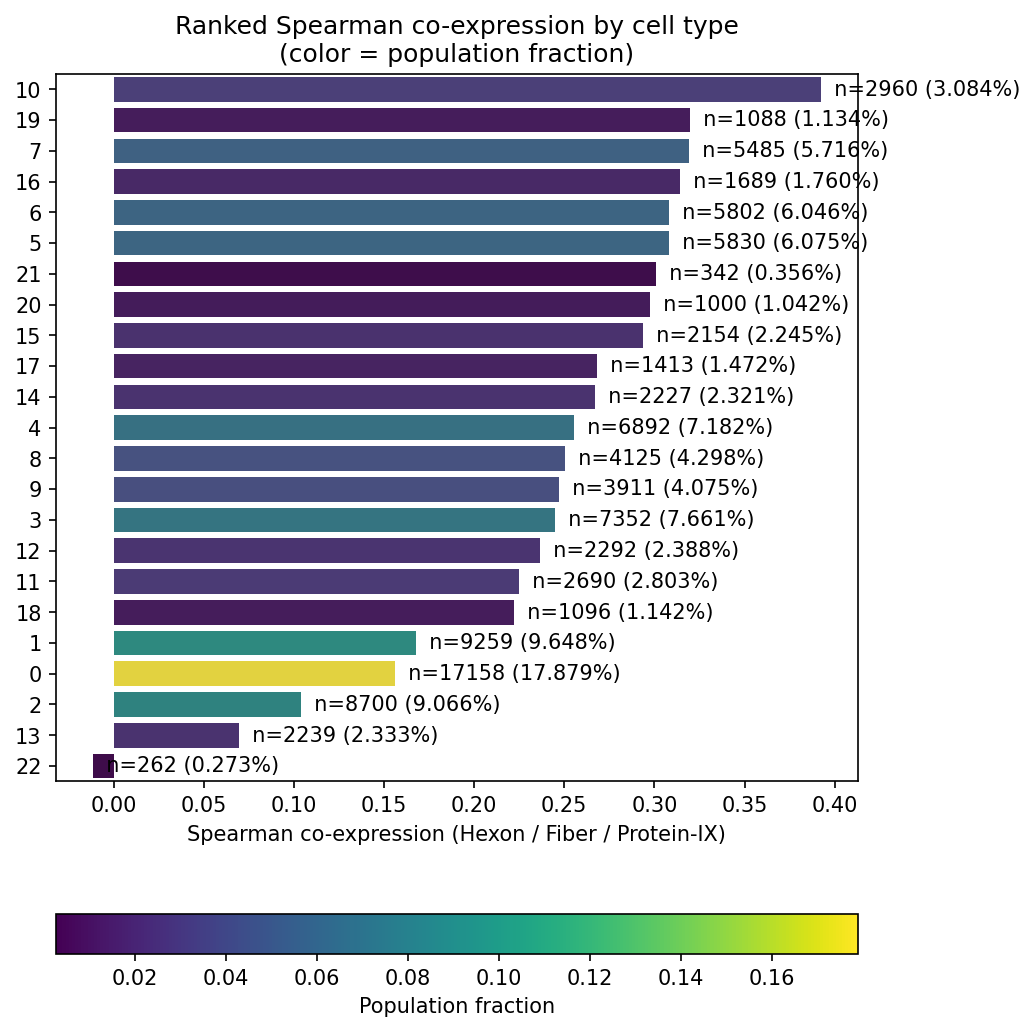

In [34]:
import matplotlib as mpl

# --- Viz: Spearman per cell type, color = population fraction ---
total_cells = df.shape[0]
scores_viz = scores.copy()
scores_viz["n_frac"] = scores_viz["n_cells"] / total_cells

scores_viz = scores_viz.sort_values("spearman_coexpr_score", ascending=False).reset_index(drop=True)

# consistent figure height
n_ct = len(scores_viz)
plt.figure(figsize=(7, 0.4*n_ct))

# continuous color mapping for n_frac
vmin = scores_viz["n_frac"].min()
vmax = scores_viz["n_frac"].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis
colors = [cmap(norm(v)) for v in scores_viz["n_frac"]]

ax = sns.barplot(
    data=scores_viz,
    x="spearman_coexpr_score",
    y="cell_type",
    palette=colors,
    dodge=False
)
ax.set_xlabel("Spearman co-expression (Hexon / Fiber / Protein-IX)")
ax.set_ylabel("")
ax.set_title("Ranked Spearman co-expression by cell type\n(color = population fraction)")

# annotate with n_cells and % of dataset
for i, row in scores_viz.iterrows():
    x = row["spearman_coexpr_score"]
    n = row["n_cells"]
    frac = row["n_frac"]
    plt.text(x, i, f"  n={n} ({frac:.3%})", va="center")

# add a continuous colorbar for population fraction
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.15, fraction=0.05)
cbar.set_label("Population fraction")

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

In [35]:
# ---- Fraction infected + Spearman correlation + annotation ----

# Align df to adata indices
df.index = adata.obs_names
ct = adata.obs.loc[df.index, "cell_type"].astype(str)

# Infection mask (triple-positive)
thresh = 0
infected = (df[present] > thresh).all(axis=1)

# Numerators / denominators
n_total_by_type = ct.value_counts()
n_inf_by_type   = ct[infected].value_counts().reindex(n_total_by_type.index, fill_value=0)
frac_infected   = (n_inf_by_type / n_total_by_type).rename("frac_infected")

# --- Spearman correlation calculation per cell type ---
spearman_scores = {}
for ct_name, gdf in df.groupby(ct):
    if len(gdf) < 3:  # too few cells
        spearman_scores[ct_name] = np.nan
        continue
    corr = gdf[present].corr(method="spearman")
    # average of upper-triangle pairwise correlations
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    vals = corr.where(mask).stack()
    spearman_scores[ct_name] = vals.mean() if not vals.empty else np.nan

spearman_scores = pd.Series(spearman_scores, name="spearman_coexpr_score")

# --- Merge into one tidy table ---
merged = (
    pd.concat([frac_infected, spearman_scores], axis=1)
      .reset_index()
      .rename(columns={"index": "cell_type"})
      .sort_values("frac_infected", ascending=False)
      .reset_index(drop=True)
)

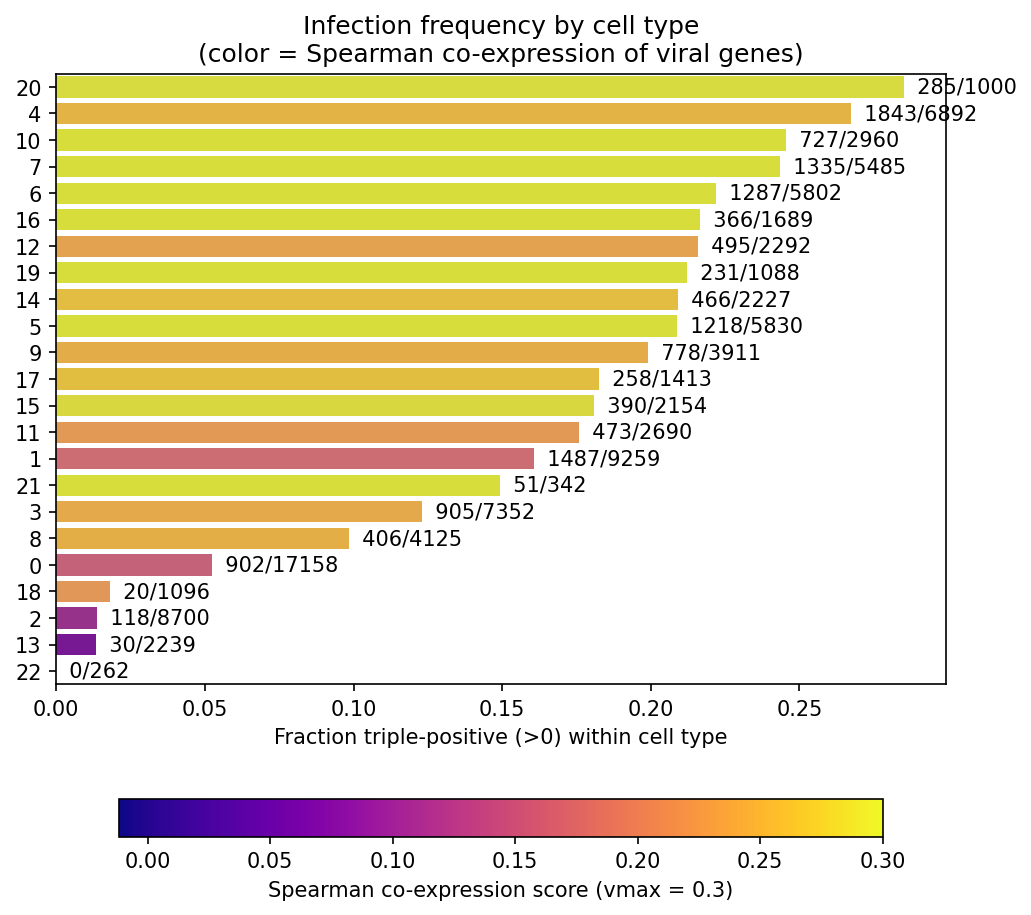

In [36]:
import matplotlib as mpl

# --- Plot: bar length = fraction infected, hue = Spearman score ---
n_ct = max(len(scores_viz), len(merged))
plt.figure(figsize=(7, 0.35*n_ct))

# cap vmax at 0.3 for better contrast
vmin = merged["spearman_coexpr_score"].min()
vmax = 0.3
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma

# sort so plotting order is clear
plot_data = merged.sort_values("frac_infected", ascending=False).reset_index(drop=True)
colors = [cmap(norm(v)) for v in plot_data["spearman_coexpr_score"]]

ax = sns.barplot(
    data=plot_data,
    x="frac_infected",
    y="cell_type",
    palette=colors,
    dodge=False
)
ax.set_xlabel(f"Fraction triple-positive (>{thresh}) within cell type")
ax.set_ylabel("")
ax.set_title("Infection frequency by cell type\n(color = Spearman co-expression of viral genes)")

# annotate infected/total
for i, row in plot_data.iterrows():
    fi = row["frac_infected"]
    ni = int(n_inf_by_type.get(row["cell_type"], 0))
    nt = int(n_total_by_type.get(row["cell_type"], 0))
    plt.text(fi, i, f"  {ni}/{nt}", va="center")

# add a continuous colorbar with capped range
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.15, fraction=0.05)
cbar.set_label("Spearman co-expression score (vmax = 0.3)")

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

In [37]:
from scipy.stats import fisher_exact
import statsmodels.stats.multitest as smm

# --- Define infection and counts from adata ---
genes = ["Hexon", "Fiber", "Protein-IX"]  # viral genes
present = [g for g in genes if g in adata.var_names]

# infection mask: triple-positive
infected = (adata[:, present].X > 0).toarray().all(axis=1) if sparse.issparse(adata.X) else (adata[:, present].X > 0).all(axis=1)

# cell type labels
ct = adata.obs["cell_type"].astype(str)

# per-type counts
n_total_by_type = ct.value_counts()
n_inf_by_type   = ct[infected].value_counts().reindex(n_total_by_type.index, fill_value=0)

# --- Fisher’s exact test per cell type ---
results = []
total_infected   = n_inf_by_type.sum()
total_cells      = n_total_by_type.sum()
total_uninfected = total_cells - total_infected

for ct_name in n_total_by_type.index:
    a = int(n_inf_by_type.get(ct_name, 0))                  # infected in this type
    b = int(n_total_by_type[ct_name] - a)                   # uninfected in this type
    c = int(total_infected - a)                             # infected in all others
    d = int(total_uninfected - b)                           # uninfected in all others

    # Fisher’s exact (odds ratio, p-value)
    OR, p = fisher_exact([[a, b], [c, d]], alternative="greater")
    results.append((ct_name, a, b, OR, p))

# --- Assemble results ---
enrichment = pd.DataFrame(results, columns=["cell_type","infected","uninfected","odds_ratio","pval"])
enrichment["n_total"] = enrichment["infected"] + enrichment["uninfected"]
enrichment["frac_infected"] = enrichment["infected"] / enrichment["n_total"]
enrichment["pval_adj"] = smm.multipletests(enrichment["pval"], method="fdr_bh")[1]

# sort
enrichment = enrichment.sort_values("pval_adj").reset_index(drop=True)

print(enrichment.head(20))

   cell_type  infected  uninfected  odds_ratio  pval  n_total  frac_infected  \
0          0     17158           0         NaN   1.0    17158            1.0   
1         20      1000           0         NaN   1.0     1000            1.0   
2         19      1088           0         NaN   1.0     1088            1.0   
3         18      1096           0         NaN   1.0     1096            1.0   
4         17      1413           0         NaN   1.0     1413            1.0   
5         16      1689           0         NaN   1.0     1689            1.0   
6         15      2154           0         NaN   1.0     2154            1.0   
7         14      2227           0         NaN   1.0     2227            1.0   
8         13      2239           0         NaN   1.0     2239            1.0   
9         12      2292           0         NaN   1.0     2292            1.0   
10        21       342           0         NaN   1.0      342            1.0   
11        11      2690           0      

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

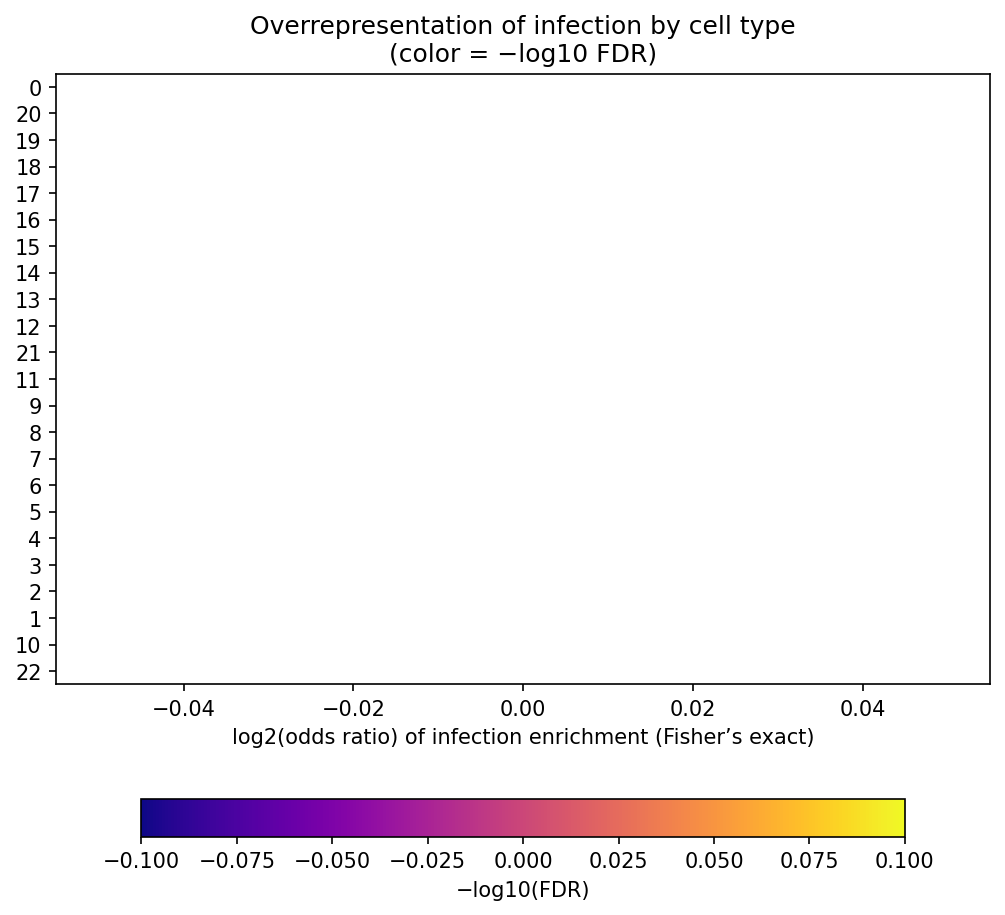

In [38]:
# --- Overrepresentation plot: clean version ---

# Filter out cell types with zero infected (OR undefined)
plot_df = enrichment[enrichment["infected"] > 0].copy()

# Compute log2 odds ratios safely
plot_df["odds_ratio"] = plot_df["odds_ratio"].replace([np.inf, -np.inf], np.nan)
plot_df["log2_or"] = np.log2(plot_df["odds_ratio"])
plot_df["log2_or"] = plot_df["log2_or"].clip(upper=5)   # cap for display

# Significance scale
plot_df["neglog10_fdr"] = -np.log10(plot_df["pval_adj"].clip(lower=1e-300))

# Sort by enrichment
plot_df = plot_df.sort_values("log2_or", ascending=False).reset_index(drop=True)

# Figure size consistent with others
n_ct = max(len(scores_viz), len(merged), len(plot_df))
plt.figure(figsize=(7, 0.35*n_ct))

# Continuous color mapping for significance
norm = mpl.colors.Normalize(vmin=0, vmax=plot_df["neglog10_fdr"].max())
cmap = plt.cm.plasma
colors = [cmap(norm(v)) for v in plot_df["neglog10_fdr"]]

# Barplot
ax = sns.barplot(
    data=plot_df,
    x="log2_or",
    y="cell_type",
    palette=colors,
    dodge=False
)
ax.set_xlabel("log2(odds ratio) of infection enrichment (Fisher’s exact)")
ax.set_ylabel("")
ax.set_title("Overrepresentation of infection by cell type\n(color = −log10 FDR)")

# Annotate infected/total and FDR
for i, row in plot_df.iterrows():
    es = row["log2_or"]
    a = int(row["infected"]); nt = int(row["n_total"])
    fdr = row["pval_adj"]
    plt.text(es, i, f"  {a}/{nt}  |  FDR={fdr:.2e}", va="center")

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.15, fraction=0.05)
cbar.set_label("−log10(FDR)")

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()